<a href="https://colab.research.google.com/github/Mon-24-K/Churn-Prediction/blob/main/churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Churn Prediction Model**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/aspirenxt_churndata.csv')
df.head(5)

,Account Name,Status,Churn,Tenure,Business Types,Total Sales,Accessories,Cloud,Networking,Services,Software,Storage,Server,Location,City,Tiers,Revenue part contributuion ( in %)
0,10i Commerce Service Pvt Ltd,Missed,1,2.0,business_gst,8.0,No,No,No,No,Yes,No,No,Karnataka,Bangalore,Tier 1,0.015389
1,24/7 Customer Private Limited,Missed,1,1.0,business_gst,3.0,Yes,No,No,No,No,No,No,Karnataka,Bangalore,Tier 1,0.003008
2,24-7 INTOUCH INDIA PRIVATE LIMITED,Existing,0,2.0,business_gst,9.0,Yes,No,Yes,No,No,No,No,Telangana,Hyderabad,Tier 1,0.008864
3,63IDEAS INFOLABS PRIVATE LIMITED,Missed,1,1.0,business_gst,1.0,No,No,No,No,No,No,No,Bangalore,Bangalore,Tier 1,0.018588
4,6th Mile Customs,Missed,1,1.0,business_gst,3.0,Yes,No,No,No,No,No,No,Karnataka,Bangalore,Tier 1,0.003008


In [ ]:
df.columns

Index(['Account Name', 'Status', 'Churn', 'Tenure', 'Business Types',
       'Total Sales', 'Accessories', 'Cloud', 'Networking', 'Services',
       'Software', 'Storage', 'Server', 'Location', 'City', 'Tiers',
       'Revenue part contributuion ( in %)'],
      dtype='object')

In [ ]:
df.shape

(817, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817 entries, 0 to 816
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Account Name                        817 non-null    object 
 1   Status                              817 non-null    object 
 2   Churn                               817 non-null    object 
 3   Tenure                              816 non-null    float64
 4   Business Types                      816 non-null    object 
 5   Total Sales                         816 non-null    float64
 6   Accessories                         817 non-null    object 
 7   Cloud                               817 non-null    object 
 8   Networking                          817 non-null    object 
 9   Services                            817 non-null    object 
 10  Software                            817 non-null    object 
 11  Storage                             817 non-n

In [ ]:
for column in df.select_dtypes(include='object'):
    print(column, df[column].unique())

Account Name ['10i Commerce Service Pvt Ltd' '24/7 Customer Private Limited'
 '24-7 INTOUCH INDIA PRIVATE LIMITED' '63IDEAS INFOLABS PRIVATE LIMITED'
 '6th Mile Customs' '9Bits Technology Pvt Ltd'
 'A N PRAKASH CONSTRUCTION PROJECT MANAGEMENT CONSULTANTS PRIVATE LIMITED'
 'A10 NETWORKS PVT LTD' 'AADEVRAJ TECH SOLUTIONS PRIVATE LIMITED'
 'Aarbee Structures Pvt Ltd' 'ABB INDIA LIMITED' 'Abinesh Enterprises'
 'Able Engineering Services Pvt.Ltd.' 'Accel India Management LLP'
 'ACCION LABS INDIA PRIVATE LIMITED' 'Accord Software & Systems Pvt. Ltd.'
 'AccountabilIT GDC India Private Limited.'
 'Accudoc Infotech Private Limited'
 'ACE CREATIVE LEARNING PRIVATE LIMITED' 'Ace Designers Ltd'
 'ACE Tech Sys Pvt Ltd' 'Act-on Software India Pvt Ltd'
 'Actoserba Active Wholesale Pvt Ltd' 'Actuant India Pvt Ltd'
 'ADECCO INDIA PRIVATE LIMITED'
 'ADITYA BIRLA MANAGEMENT CORPORATION PVT LTD'
 'Adroit Facilities Management Services Pvt Ltd'
 'AFFINTRIX TECHNOLOGIES PRIVATE LIMITED' 'Aibono Smart Farmin

In [ ]:
print("STATUS NOT FOUNDS COUNTS: ",(df["Status"]=="NOT FOUND").sum())
print("CHURN NOT FOUNDS COUNTS: ",(df["Churn"]=="NOT FOUND").sum())
print("CHURN NULL COUNTS: ",df["Business Types"].isnull().sum())
print("TIERS NOT FOUNDS COUNT: ",(df["Tiers"].isnull().sum()))

STATUS NOT FOUNDS COUNTS:  1
CHURN NOT FOUNDS COUNTS:  1
CHURN NULL COUNTS:  1
TIERS NOT FOUNDS COUNT:  1


In [ ]:
df.dropna()
df.drop(df[df["Status"] == "NOT FOUND"].index, inplace=True)
df.drop(df[df["Churn"] == "NOT FOUND"].index, inplace=True)

In [ ]:
df.isnull().sum()

,0
Account Name,0
Status,0
Churn,0
Tenure,0
Business Types,0
Total Sales,0
Accessories,0
Cloud,0
Networking,0
Services,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Status"].unique()

array(['Missed', 'Existing', 'New Customer'], dtype=object)

In [ ]:
df["Churn"].unique()

array(['1', '0'], dtype=object)

In [ ]:
df.replace({"Status":{"Missed":1,
                      "Existing":0,
                      "New Customer":0}},
           inplace=True)

<ipython-input-26-5cfeff5364f8>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Status":{"Missed":1,


In [ ]:
df.replace({"Business Types": {
    "business_gst": 1,
    "business_registered_composition": 1,
    "business_none": 2,
    "business_sez": 3,
    "overseas": 4
}}, inplace=True)

<ipython-input-27-94ca15469732>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Business Types": {


In [ ]:
df.replace({"Tiers":{"Tier 1": 1,
                     "Tier 2": 2,
                     "Tier 3": 3}},
           inplace=True)

<ipython-input-28-2a5f52903968>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Tiers":{"Tier 1": 1,


In [ ]:
df.replace({"Yes": 1, "No": 0}, inplace=True)

<ipython-input-29-6778fb653691>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Yes": 1, "No": 0}, inplace=True)


In [ ]:
df= df.rename(columns={"Revenue part contributuion ( in %)":"Revenue%"})

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Status,816.0,0.838235,0.368461,0.00000,1.000000,1.000000,1.000000,1.000000
Tenure,816.0,2.042892,1.544235,1.00000,1.000000,1.000000,3.000000,8.000000
Business Types,816.0,1.154412,0.483525,1.00000,1.000000,1.000000,1.000000,4.000000
Total Sales,816.0,24.906863,98.674509,1.00000,2.000000,4.000000,14.000000,2008.000000
Accessories,816.0,0.383578,0.486555,0.00000,0.000000,0.000000,1.000000,1.000000
Cloud,816.0,0.041667,0.199949,0.00000,0.000000,0.000000,0.000000,1.000000
Networking,816.0,0.153186,0.360388,0.00000,0.000000,0.000000,0.000000,1.000000
Services,816.0,0.294118,0.455925,0.00000,0.000000,0.000000,1.000000,1.000000
Software,816.0,0.279412,0.448985,0.00000,0.000000,0.000000,1.000000,1.000000
Storage,816.0,0.025735,0.158442,0.00000,0.000000,0.000000,0.000000,1.000000


In [ ]:
df.drop("Account Name", inplace = True, axis =1)
df.drop("Location",inplace = True, axis =1)
df.drop("City",inplace = True, axis=1)

In [ ]:
df.groupby(['Tiers','Churn'])['Churn'].count()

Tiers  Churn
1      0        119
       1        634
2      0          6
       1         27
3      0          7
       1         23
Name: Churn, dtype: int64

In [ ]:
df.groupby(['Tenure','Churn'])['Churn'].count()

Tenure  Churn
1.0     0         31
        1        404
2.0     0         28
        1        148
3.0     0         13
        1         72
4.0     0         21
        1         29
5.0     0         10
        1         12
6.0     0         16
        1         13
7.0     0          7
        1          4
8.0     0          6
        1          2
Name: Churn, dtype: int64

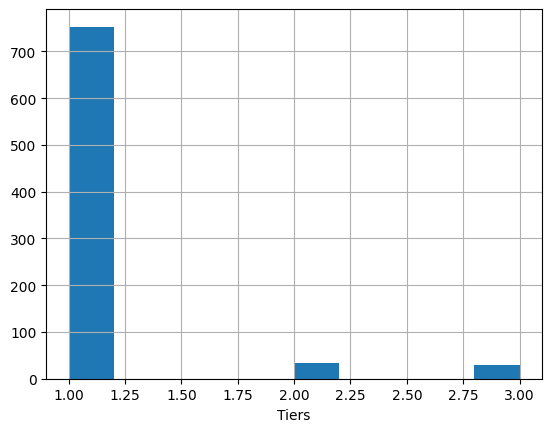

In [ ]:
df['Tiers'].hist()
plt.xlabel("Tiers")
plt.show()

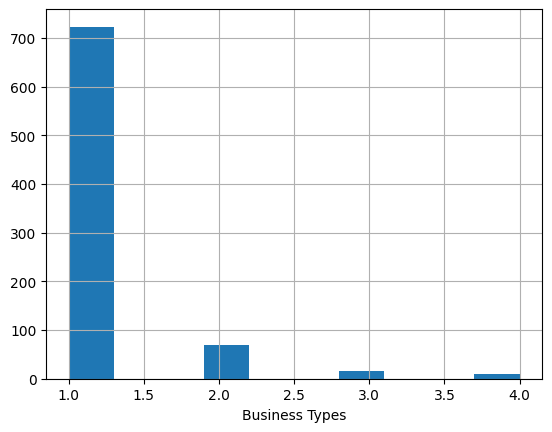

In [ ]:
df['Business Types'].hist()
plt.xlabel("Business Types")
plt.show()

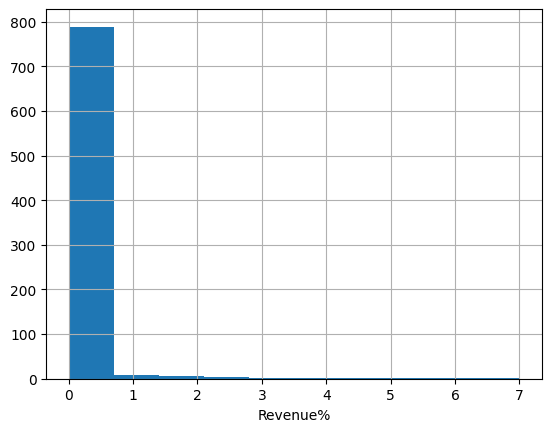

In [ ]:
df['Revenue%'].hist()
plt.xlabel("Revenue%")
plt.show()

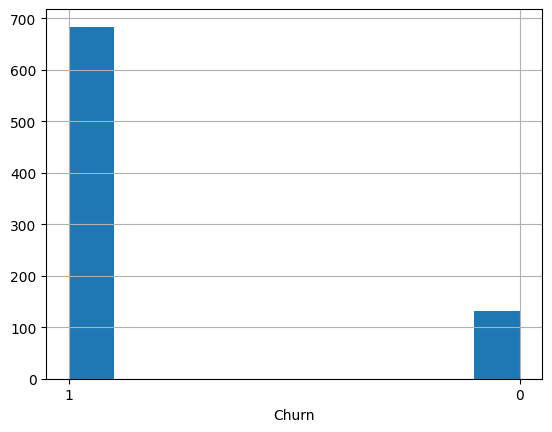

In [ ]:
df['Churn'].hist()
plt.xlabel("Churn")
plt.show()

<Axes: xlabel='Tiers', ylabel='Total Sales'>

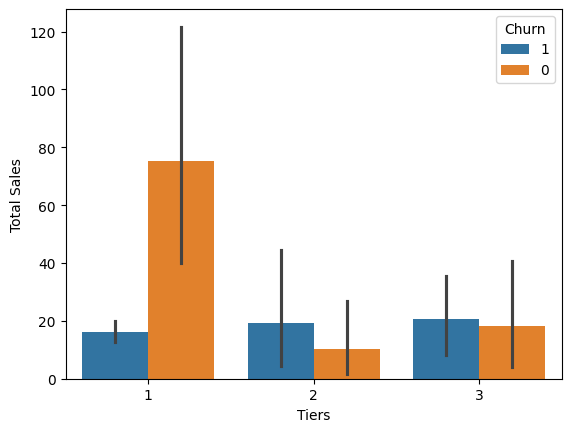

In [ ]:
sns.barplot(data=df, x='Tiers',y='Total Sales',hue='Churn')

<Axes: ylabel='Tenure'>

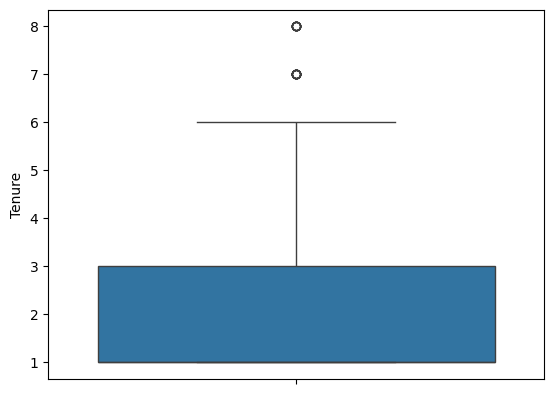

In [ ]:
sns.boxplot(data=df, y='Tenure')

<Axes: xlabel='Tenure', ylabel='Total Sales'>

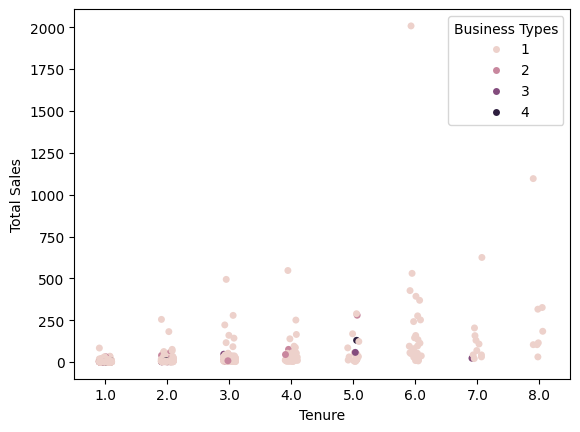

In [ ]:
sns.stripplot(x='Tenure',y='Total Sales',data=df,hue='Business Types')

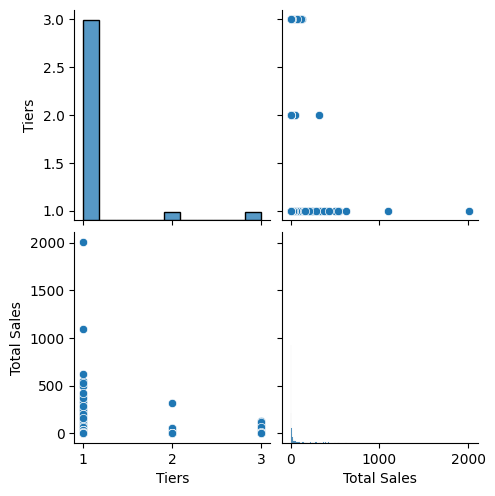

In [ ]:
sns.pairplot(data=df[['Tiers','Total Sales']])
plt.show()

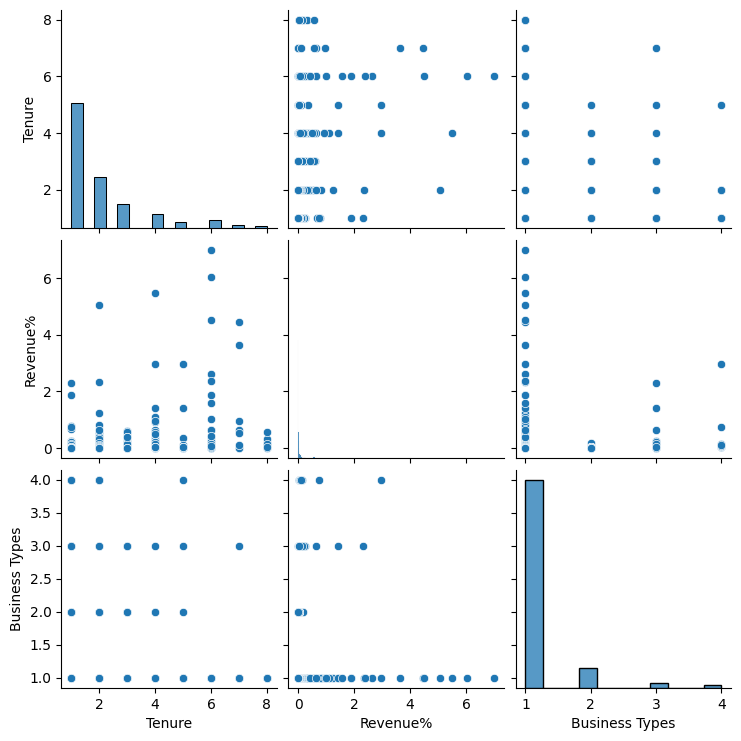

In [ ]:
sns.pairplot(data=df[['Tenure','Revenue%','Business Types']])

In [ ]:
cor= df.corr()
print(cor)

                  Status     Churn    Tenure  Business Types  Total Sales  \
Status          1.000000  1.000000 -0.395358        0.078391    -0.198177   
Churn           1.000000  1.000000 -0.395358        0.078391    -0.198177   
Tenure         -0.395358 -0.395358  1.000000       -0.058179     0.432680   
Business Types  0.078391  0.078391 -0.058179        1.000000    -0.032744   
Total Sales    -0.198177 -0.198177  0.432680       -0.032744     1.000000   
Accessories    -0.098334 -0.098334  0.079325       -0.012157     0.095382   
Cloud           0.058291  0.058291  0.097525        0.022210     0.027498   
Networking     -0.136565 -0.136565  0.082983       -0.037329     0.118577   
Services       -0.074329 -0.074329  0.149364        0.083160     0.092249   
Software       -0.178877 -0.178877  0.161432       -0.102897     0.086083   
Storage        -0.012672 -0.012672  0.015542        0.044162     0.035549   
Server         -0.115293 -0.115293  0.109362        0.003809     0.108866   

<Axes: >

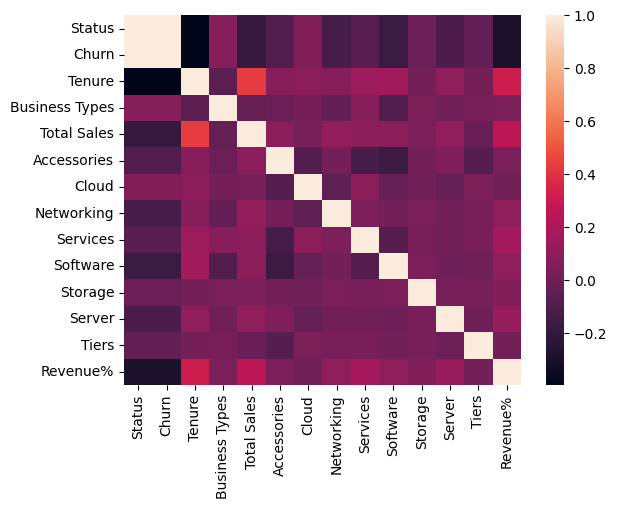

In [ ]:
sns.heatmap(cor)

In [ ]:
df.drop("Status",inplace=True,axis=1)

In [ ]:
df.head()

,Churn,Tenure,Business Types,Total Sales,Accessories,Cloud,Networking,Services,Software,Storage,Server,Tiers,Revenue%
0,1,2.0,1,8.0,0,0,0,0,1,0,0,1,0.015389
1,1,1.0,1,3.0,1,0,0,0,0,0,0,1,0.003008
2,0,2.0,1,9.0,1,0,1,0,0,0,0,1,0.008864
3,1,1.0,1,1.0,0,0,0,0,0,0,0,1,0.018588
4,1,1.0,1,3.0,1,0,0,0,0,0,0,1,0.003008


In [ ]:
df.dtypes

,0
Churn,object
Tenure,float64
Business Types,int64
Total Sales,float64
Accessories,int64
Cloud,int64
Networking,int64
Services,int64
Software,int64
Storage,int64


In [ ]:
df.head()

,Churn,Tenure,Business Types,Total Sales,Accessories,Cloud,Networking,Services,Software,Storage,Server,Tiers,Revenue%
0,1,2.0,1,8.0,0,0,0,0,1,0,0,1,0.015389
1,1,1.0,1,3.0,1,0,0,0,0,0,0,1,0.003008
2,0,2.0,1,9.0,1,0,1,0,0,0,0,1,0.008864
3,1,1.0,1,1.0,0,0,0,0,0,0,0,1,0.018588
4,1,1.0,1,3.0,1,0,0,0,0,0,0,1,0.003008


In [ ]:
#df['Infrastructure_Services'] = df[['Cloud', 'Server', 'Storage']].sum(axis=1)

In [ ]:
#df.drop(['Cloud', 'Server', 'Storage'],axis=1,inplace=True)


In [ ]:
#df.head(2)

In [ ]:
df['Churn'] = df['Churn'].astype('int64')

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn",axis=1)
y=df['Churn']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Now you can iterate through the columns using the DataFrame's columns attribute
for col in X.columns:  # Iterate through columns
    print(f"Feature: {col}")
    print(pd.crosstab(X[col], y))
    print("\n")

Feature: Tenure
Churn    0    1
Tenure         
1.0     31  404
2.0     28  148
3.0     13   72
4.0     21   29
5.0     10   12
6.0     16   13
7.0      7    4
8.0      6    2


Feature: Business Types
Churn             0    1
Business Types          
1               126  597
2                 3   66
3                 3   12
4                 0    9


Feature: Total Sales
Churn         0    1
Total Sales         
1.0          22  176
2.0          10   98
3.0           3   59
4.0           5   44
5.0           8   27
...          ..  ...
530.0         0    1
547.0         0    1
625.0         1    0
1096.0        1    0
2008.0        1    0

[105 rows x 2 columns]


Feature: Accessories
Churn         0    1
Accessories         
0            67  436
1            65  248


Feature: Cloud
Churn    0    1
Cloud          
0      130  652
1        2   32


Feature: Networking
Churn        0    1
Networking         
0           97  594
1           35   90


Feature: Services
Churn      0    1


In [ ]:
import statsmodels.api as sm
import pandas as pd

# Add a constant term for the intercept
X_train_sm = sm.add_constant(X_train)

# Fit the model using statsmodels
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# Display the summary with p-values and coefficients
print(result.summary())


Optimization terminated successfully.
         Current function value: 0.326346
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                  652
Model:                          Logit   Df Residuals:                      639
Method:                           MLE   Df Model:                           12
Date:                Fri, 02 May 2025   Pseudo R-squ.:                  0.2606
Time:                        06:10:39   Log-Likelihood:                -212.78
converged:                       True   LL-Null:                       -287.79
Covariance Type:            nonrobust   LLR p-value:                 5.608e-26
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              2.8815      0.631      4.570      0.000       1.646       4.117
Tenure           

In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr= lr.predict(X_test)
# regression coefficients
print("Logistic Regression")
print("Independent variables: ",X_train.columns)
print('Coefficients: ', lr.coef_)

accuracy_lr= accuracy_score(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
class_report_lr= classification_report(y_test, y_pred_lr)
print("Accuracy: ",accuracy_lr)
print("Confusion matrix: ", conf_matrix_lr)
print("Classification report: ",class_report_lr)

Logistic Regression
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Coefficients:  [[-4.88902292e-01  7.94119754e-01  3.87653196e-04 -5.52971160e-01
   1.16329375e+00 -5.81819236e-01 -1.53962442e-01 -8.13056453e-01
   4.35698860e-01 -6.89993914e-01 -1.79805499e-01 -1.11917968e+00]]
Accuracy:  0.8353658536585366
Confusion matrix:  [[  6  21]
 [  6 131]]
Classification report:                precision    recall  f1-score   support

           0       0.50      0.22      0.31        27
           1       0.86      0.96      0.91       137

    accuracy                           0.84       164
   macro avg       0.68      0.59      0.61       164
weighted avg       0.80      0.84      0.81       164



In [ ]:
# Artificial Neural Network (ANN)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

#encode categorical features
label_encoder = LabelEncoder()
for col in X_train.select_dtypes(include=['object']).columns:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
# Predict
y_pred_ann = ann.predict(X_test)
y_pred_ann = (y_pred_ann > 0.5).astype(int)

# Model summary
print("Artificial Neural Network (ANN)")
print("Independent variables: ", X_train.columns)


accuracy_ann = accuracy_score(y_test, y_pred_ann)
conf_matrix_ann = confusion_matrix(y_test, y_pred_ann)
class_report_ann = classification_report(y_test, y_pred_ann)
print("Accuracy: ", accuracy_ann)
print("Confusion matrix: ", conf_matrix_ann)
print("Classification report: ", class_report_ann)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Artificial Neural Network (ANN)
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Accuracy:  0.8475609756097561
Confusion matrix:  [[  6  21]
 [  4 133]]
Classification report:                precision    recall  f1-score   support

           0       0.60      0.22      0.32        27
           1       0.86      0.97      0.91       137

    accuracy                           0.85       164
   macro avg       0.73      0.60      0.62       164
weighted avg       0.82      0.85      0.82       164



In [ ]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Gradient Boosting Classifier")
print("Independent variables: ", X_train.columns)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)
class_report_gb = classification_report(y_test, y_pred_gb)

print("Accuracy: ", accuracy_gb)
print("Confusion matrix: ", conf_matrix_gb)
print("Classification report: ", class_report_gb)


Gradient Boosting Classifier
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Accuracy:  0.8597560975609756
Confusion matrix:  [[ 10  17]
 [  6 131]]
Classification report:                precision    recall  f1-score   support

           0       0.62      0.37      0.47        27
           1       0.89      0.96      0.92       137

    accuracy                           0.86       164
   macro avg       0.76      0.66      0.69       164
weighted avg       0.84      0.86      0.84       164



In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Classifier")
print("Independent variables: ", X_train.columns)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print("Accuracy: ", accuracy_rf)
print("Confusion matrix: ", conf_matrix_rf)
print("Classification report: ", class_report_rf)

Random Forest Classifier
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Accuracy:  0.8536585365853658
Confusion matrix:  [[  7  20]
 [  4 133]]
Classification report:                precision    recall  f1-score   support

           0       0.64      0.26      0.37        27
           1       0.87      0.97      0.92       137

    accuracy                           0.85       164
   macro avg       0.75      0.62      0.64       164
weighted avg       0.83      0.85      0.83       164



In [ ]:
# Support Vector Machine Classifier
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

svm_clf = svm.SVC(kernel='poly')  # Using polynomial kernel
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

print("Support Vector Machine Classifier")
print("Independent variables: ", X_train.columns)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)

print("Accuracy: ", accuracy_svm)
print("Confusion matrix: ", conf_matrix_svm)
print("Classification report: ", class_report_svm)


Support Vector Machine Classifier
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Accuracy:  0.8292682926829268
Confusion matrix:  [[  0  27]
 [  1 136]]
Classification report:                precision    recall  f1-score   support

           0       0.00      0.00      0.00        27
           1       0.83      0.99      0.91       137

    accuracy                           0.83       164
   macro avg       0.42      0.50      0.45       164
weighted avg       0.70      0.83      0.76       164



In [ ]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

print("Decision Tree Classifier")
print("Independent variables: ", X_train.columns)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
class_report_dt = classification_report(y_test, y_pred_dt)

print("Accuracy: ", accuracy_dt)
print("Confusion matrix: ", conf_matrix_dt)
print("Classification report: ", class_report_dt)


Decision Tree Classifier
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Accuracy:  0.8292682926829268
Confusion matrix:  [[ 12  15]
 [ 13 124]]
Classification report:                precision    recall  f1-score   support

           0       0.48      0.44      0.46        27
           1       0.89      0.91      0.90       137

    accuracy                           0.83       164
   macro avg       0.69      0.67      0.68       164
weighted avg       0.82      0.83      0.83       164



In [ ]:
#!pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# Apply SMOTE to balance the data
smote = SMOTE(random_state=42)  # Initialize SMOTE
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)


In [ ]:
# Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_classifier.fit(X_resampled, y_resampled)
gb_y_pred = gb_classifier.predict(X_test)

print("Gradient Boosting Classifier")
print("Independent variables: ", X_train.columns)

gb_accuracy = accuracy_score(y_test, gb_y_pred)
conf_matrix_gb = confusion_matrix(y_test, gb_y_pred)
class_report_gb = classification_report(y_test, gb_y_pred)

print("Accuracy: ", gb_accuracy)
print("Confusion matrix: ", conf_matrix_gb)
print("Classification report: ", class_report_gb)

Gradient Boosting Classifier
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Accuracy:  0.8536585365853658
Confusion matrix:  [[ 16  11]
 [ 13 124]]
Classification report:                precision    recall  f1-score   support

           0       0.55      0.59      0.57        27
           1       0.92      0.91      0.91       137

    accuracy                           0.85       164
   macro avg       0.74      0.75      0.74       164
weighted avg       0.86      0.85      0.86       164



In [ ]:
# SVM (Linear Kernel)
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

svm_linear = svm.SVC(kernel='linear')
svm_linear.fit(X_resampled, y_resampled)
svm_linear_y_pred = svm_linear.predict(X_test)

print("SVM (Linear Kernel)")
print("Independent variables: ", X_train.columns)

svm_linear_accuracy = accuracy_score(y_test, svm_linear_y_pred)
conf_matrix_svm_linear = confusion_matrix(y_test, svm_linear_y_pred)
class_report_svm_linear = classification_report(y_test, svm_linear_y_pred)

print("Accuracy: ", svm_linear_accuracy)
print("Confusion matrix: ", conf_matrix_svm_linear)
print("Classification report: ", class_report_svm_linear)

SVM (Linear Kernel)
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Accuracy:  0.7682926829268293
Confusion matrix:  [[ 12  15]
 [ 23 114]]
Classification report:                precision    recall  f1-score   support

           0       0.34      0.44      0.39        27
           1       0.88      0.83      0.86       137

    accuracy                           0.77       164
   macro avg       0.61      0.64      0.62       164
weighted avg       0.79      0.77      0.78       164



In [ ]:
# Random Forest
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_resampled, y_resampled)
rf_y_pred = rf_classifier.predict(X_test)

print("Random Forest Classifier")
print("Independent variables: ", X_train.columns)

accuracy_rf = accuracy_score(y_test, rf_y_pred)
conf_matrix_rf = confusion_matrix(y_test, rf_y_pred)
class_report_rf = classification_report(y_test, rf_y_pred)

print("Accuracy: ", accuracy_rf)
print("Confusion matrix: ", conf_matrix_rf)
print("Classification report: ", class_report_rf)

Random Forest Classifier
Independent variables:  Index(['Tenure', 'Business Types', 'Total Sales', 'Accessories', 'Cloud',
       'Networking', 'Services', 'Software', 'Storage', 'Server', 'Tiers',
       'Revenue%'],
      dtype='object')
Accuracy:  0.823170731707317
Confusion matrix:  [[ 13  14]
 [ 15 122]]
Classification report:                precision    recall  f1-score   support

           0       0.46      0.48      0.47        27
           1       0.90      0.89      0.89       137

    accuracy                           0.82       164
   macro avg       0.68      0.69      0.68       164
weighted avg       0.83      0.82      0.82       164



In [ ]:
#Artificial neural network (after SWOTE)
# Initialize the ANN (MLP Classifier)
from sklearn.neural_network import MLPClassifier

ann_classifier = MLPClassifier(hidden_layer_sizes=(64, 32),  # Adjust hidden layer sizes as needed
                                activation='relu',
                                solver='adam',
                                max_iter=200,  # Adjust as needed
                                random_state=42)

# Train the classifier
ann_classifier.fit(X_resampled, y_resampled)

#Artificial neural network (after SWOTE)
# Initialize the ANN (MLP Classifier)
ann_classifier = MLPClassifier(hidden_layer_sizes=(64, 32),  # Adjust hidden layer sizes as needed
                                activation='relu',
                                solver='adam',
                                max_iter=200,  # Adjust as needed
                                random_state=42)

# Train the classifier
ann_classifier.fit(X_resampled, y_resampled)

# Make predictions
y_pred_ann = ann_classifier.predict(X_test)
accuracy_ann = accuracy_score(y_test, y_pred_ann)
conf_matrix_ann = confusion_matrix(y_test, y_pred_ann)
class_report_ann = classification_report(y_test, y_pred_ann)

# Evaluate the model
print("Accuracy: ", accuracy_ann)
print("Confusion matrix: ", conf_matrix_ann)
print("Classification report: ", class_report_ann)

# Evaluate the model
print("Accuracy: ", accuracy_ann)
print("Confusion matrix: ", conf_matrix_ann)
print("Classification report: ", class_report_ann)

Accuracy:  0.7439024390243902
Confusion matrix:  [[ 17  10]
 [ 32 105]]
Classification report:                precision    recall  f1-score   support

           0       0.35      0.63      0.45        27
           1       0.91      0.77      0.83       137

    accuracy                           0.74       164
   macro avg       0.63      0.70      0.64       164
weighted avg       0.82      0.74      0.77       164

Accuracy:  0.7439024390243902
Confusion matrix:  [[ 17  10]
 [ 32 105]]
Classification report:                precision    recall  f1-score   support

           0       0.35      0.63      0.45        27
           1       0.91      0.77      0.83       137

    accuracy                           0.74       164
   macro avg       0.63      0.70      0.64       164
weighted avg       0.82      0.74      0.77       164



In [ ]:
# prompt: use decision tree and logical regrssion

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming X and y are defined and preprocessed from the previous code with SMOTE
# X_train, X_test, y_train, y_test


# Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_resampled, y_resampled)
dt_predictions = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy}")

# Logistic Regression
lr_classifier = LogisticRegression(random_state=42)
lr_classifier.fit(X_resampled, y_resampled)
lr_predictions = lr_classifier.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_conf_matrix=confusion_matrix(y_test,lr_predictions)
lr_class_report=classification_report(y_test,lr_predictions)
print(lr_conf_matrix)
print(lr_class_report)
print(f"Logistic Regression Accuracy: {lr_accuracy}")


Decision Tree Accuracy: 0.7804878048780488
[[ 13  14]
 [ 18 119]]
              precision    recall  f1-score   support

           0       0.42      0.48      0.45        27
           1       0.89      0.87      0.88       137

    accuracy                           0.80       164
   macro avg       0.66      0.68      0.66       164
weighted avg       0.82      0.80      0.81       164

Logistic Regression Accuracy: 0.8048780487804879


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
